In [1]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

sns.set_palette('husl')
%matplotlib inline

# Загрузка данных


In [2]:


df = pd.read_csv('cirrhosis.csv')
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


# Анализ данных

In [3]:

df.shape

(418, 20)

In [4]:


df.head(10)

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
5,6,2503,D,Placebo,24201,F,N,Y,N,N,0.8,248.0,3.98,50.0,944.0,93.00,63.0,NaN,11.0,3.0
6,7,1832,C,Placebo,20284,F,N,Y,N,N,1.0,322.0,4.09,52.0,824.0,60.45,213.0,204.0,9.7,3.0
7,8,2466,D,Placebo,19379,F,N,N,N,N,0.3,280.0,4.00,52.0,4651.2,28.38,189.0,373.0,11.0,3.0
8,9,2400,D,D-penicillamine,15526,F,N,N,Y,N,3.2,562.0,3.08,79.0,2276.0,144.15,88.0,251.0,11.0,2.0
9,10,51,D,Placebo,25772,F,Y,N,Y,Y,12.6,200.0,2.74,140.0,918.0,147.25,143.0,302.0,11.5,4.0


In [5]:


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [6]:


df.describe()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,209.500000,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,120.810458,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,1.000000,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,105.250000,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,209.500000,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,418.000000,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


In [7]:


df.columns.tolist()

['ID',
 'N_Days',
 'Status',
 'Drug',
 'Age',
 'Sex',
 'Ascites',
 'Hepatomegaly',
 'Spiders',
 'Edema',
 'Bilirubin',
 'Cholesterol',
 'Albumin',
 'Copper',
 'Alk_Phos',
 'SGOT',
 'Tryglicerides',
 'Platelets',
 'Prothrombin',
 'Stage']

In [8]:


df['Status'].unique()

array(['D', 'C', 'CL'], dtype=object)

In [33]:


df['Status'].value_counts()

,count
Status,
C,168
D,125
CL,19


Видим, что целевая переменная `Status` содержит 3 класса:

- `C` — цензурированные наблюдения,
- `CL` — пересадка печени,
- `D` — смерть.

Также заметно, что классы **несбалансированы**, особенно класс `CL`.

In [34]:


df.isna().sum().sort_values(ascending=False)

,0
ID,0
N_Days,0
Status,0
Drug,0
Age,0
Sex,0
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0


В датасете есть пропуски, поэтому перед обучением модели их нужно обработать.

In [51]:
df = df[df["Status"].notna()]
df.dropna(subset=['Drug'], inplace=True)
df.Cholesterol = df.Cholesterol.fillna(df.Cholesterol.median())
df.Tryglicerides = df.Tryglicerides.fillna(df.Tryglicerides.median())
df.Copper = df.Copper.fillna(df.Copper.median())
df.Platelets = df.Platelets.fillna(df.Platelets.median())

categorical_cols = df.select_dtypes(exclude=['number']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [53]:
df.isna().sum().sort_values(ascending=False)

,0
ID,0
N_Days,0
Status,0
Drug,0
Age,0
Sex,0
Ascites,0
Hepatomegaly,0
Spiders,0
Edema,0


# Визуализация данных

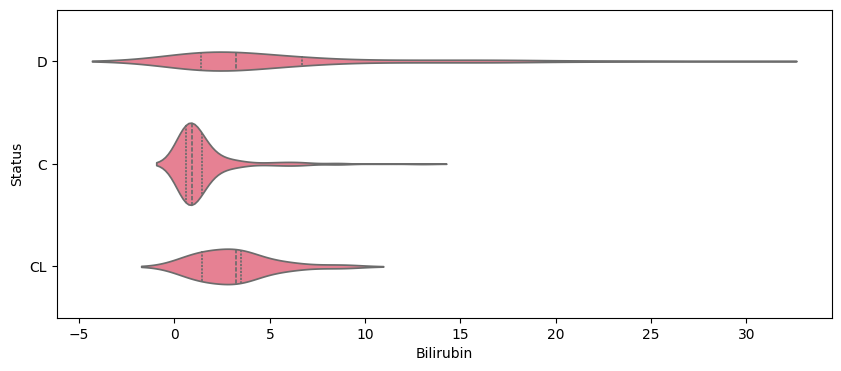

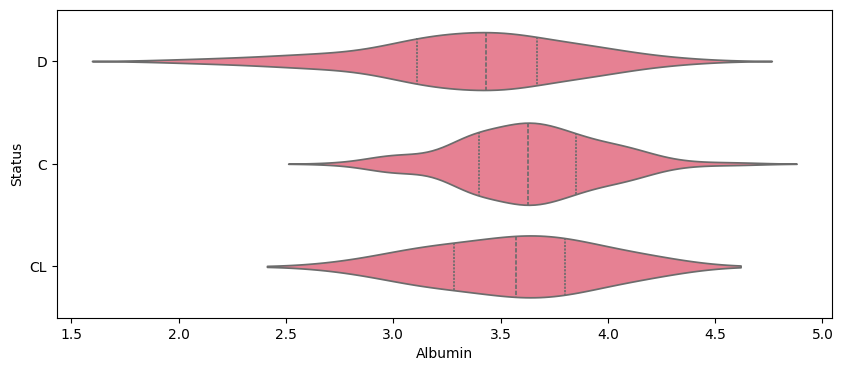

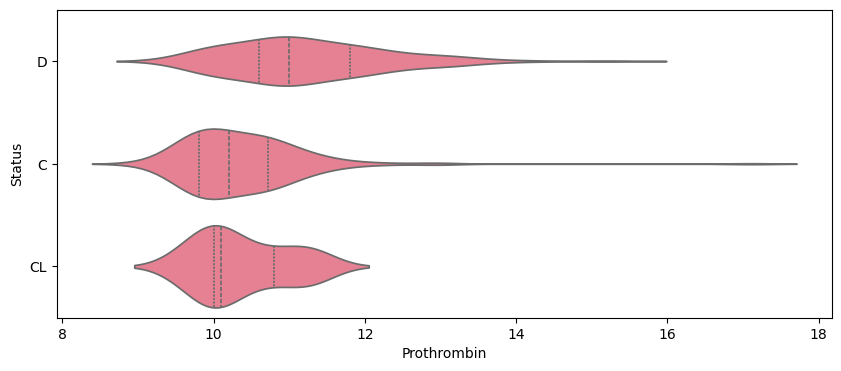

In [54]:
# скрипичные графики для нескольких информативных признаков

plt.figure(figsize=(10, 4))
sns.violinplot(y='Status', x='Bilirubin', data=df, inner='quartile')
plt.show()

plt.figure(figsize=(10, 4))
sns.violinplot(y='Status', x='Albumin', data=df, inner='quartile')
plt.show()

plt.figure(figsize=(10, 4))
sns.violinplot(y='Status', x='Prothrombin', data=df, inner='quartile')
plt.show()

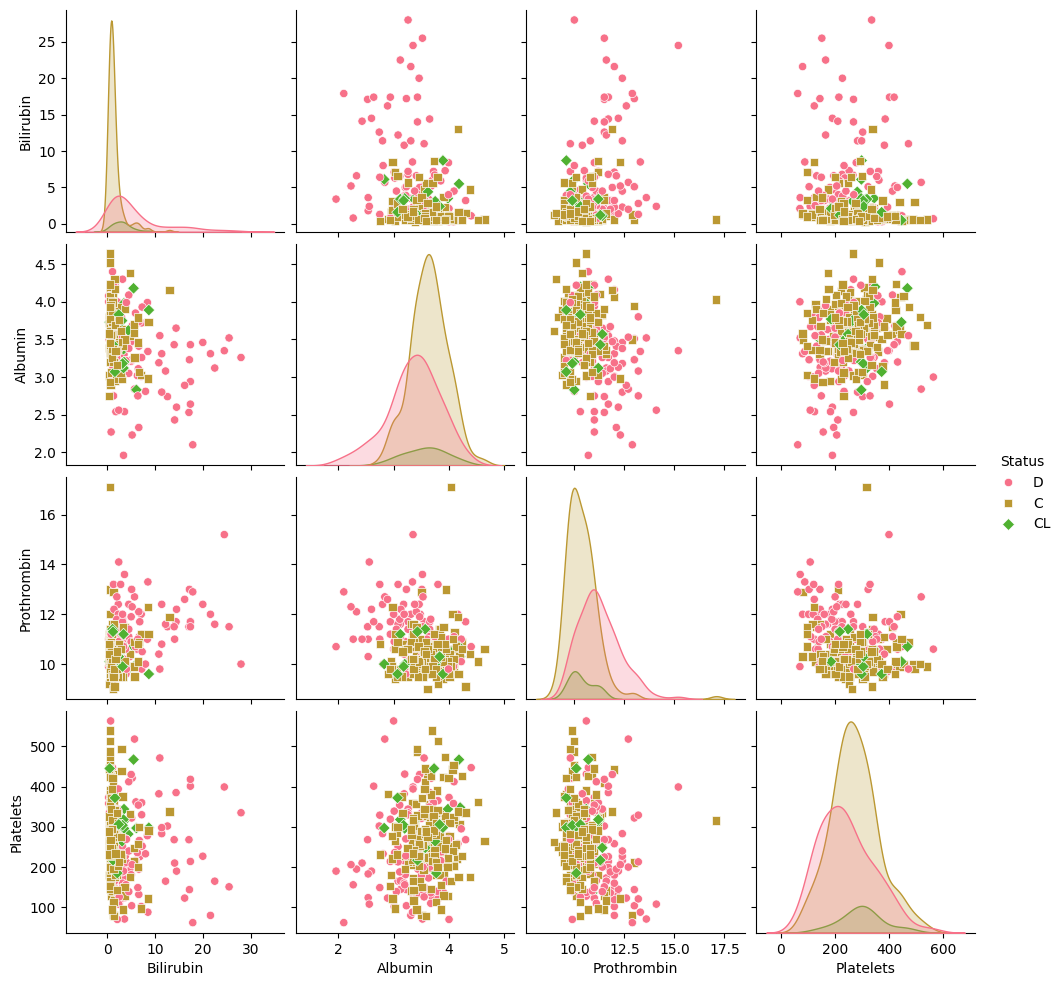

In [55]:
# аарный график по части числовых признаков

pairplot_cols = ['Status', 'Bilirubin', 'Albumin', 'Prothrombin', 'Platelets']
sns.pairplot(df[pairplot_cols].dropna(), hue='Status', markers=['o', 's', 'D'])
plt.show()

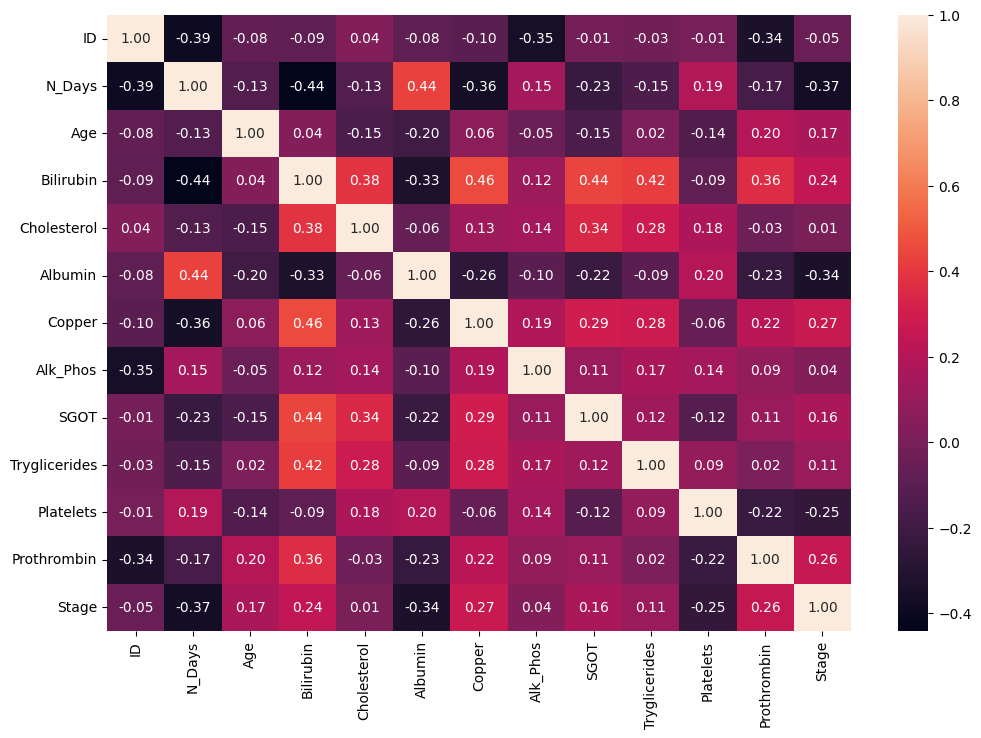

In [56]:
# тепловая карта корреляций для числовых признаков

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f')
plt.show()

По графикам видно, что классы различаются по нескольким медицинским показателям, особенно по `Bilirubin`, `Albumin` и `Prothrombin`.

# Подготовка данных

In [57]:
data = df.drop(columns=['ID']).copy()
data.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [58]:


X = data.drop(columns=['Status']).copy()
y = data['Status'].copy()

print(f'X shape: {X.shape} | y shape: {y.shape}')

X shape: (312, 18) | y shape: (312,)


In [59]:
# преобразуем категориальные признаки в числовые при помощи one-hot encoding

X = pd.get_dummies(X, drop_first=True)

# кодируем целевую переменную
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print('Классы после кодирования:', dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
print(f'Новая размерность X: {X.shape}')

Классы после кодирования: {'C': np.int64(0), 'CL': np.int64(1), 'D': np.int64(2)}
Новая размерность X: (312, 19)




Разделяем данные на обучающую и тестовую выборки.
Используем stratify, чтобы сохранить пропорции классов в обеих выборках.

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(249, 19) (63, 19) (249,) (63,)


# Обучение и выбор оптимальной модели

Сравним несколько алгоритмов классификации:

- Logistic Regression (LR)
- Linear Discriminant Analysis (LDA)
- K-Nearest Neighbors (KNN)
- Classification and Regression Trees (CART)

In [61]:
# список моделей

models = []
models.append(('LR', Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000))
])))
models.append(('LDA', Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearDiscriminantAnalysis())
])))
models.append(('KNN', Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])))
models.append(('CART', Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))
])))

In [62]:
# оценим модели с помощью кросс-валидации на обучающей выборке

results = []
names = []

for name, model in models:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(f'{name}: {cv_results.mean():.4f} (+/- {cv_results.std():.4f})')

LR: 0.6952 (+/- 0.0624)
LDA: 0.7111 (+/- 0.0519)
KNN: 0.6708 (+/- 0.0540)
CART: 0.6710 (+/- 0.0754)


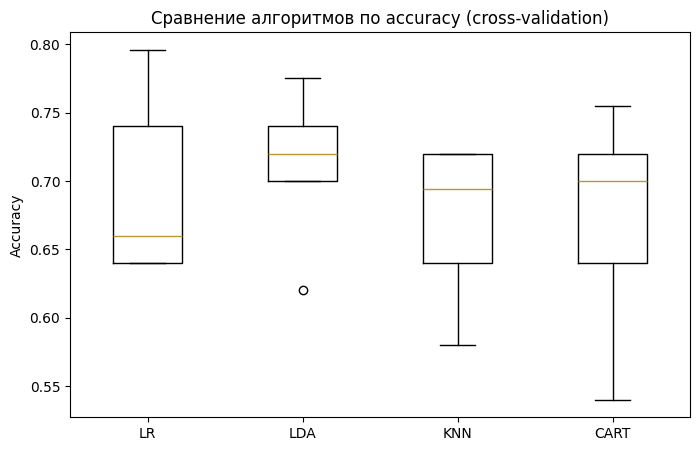

In [63]:
# сравнение моделей на boxplot

plt.figure(figsize=(8, 5))
plt.boxplot(results, tick_labels=names)
plt.title('Сравнение алгоритмов по accuracy (cross-validation)')
plt.ylabel('Accuracy')
plt.show()

По среднему значению accuracy выбираем модель, которая показывает лучший результат на кросс-валидации.

In [64]:
# обучим модели и оценим

test_scores = []

for name, model in models:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    test_scores.append((name, acc))
    print(f'{name} test accuracy: {acc:.4f}')

LR test accuracy: 0.7460
LDA test accuracy: 0.7619
KNN test accuracy: 0.7619
CART test accuracy: 0.6190


In [65]:
# выберем лучшую

best_name, best_score = max(test_scores, key=lambda x: x[1])
print('Лучшая модель:', best_name)
print('Accuracy на тесте:', round(best_score, 4))

Лучшая модель: LDA
Accuracy на тесте: 0.7619


# Обучение лучшей модели и подробная оценка

In [66]:
# найдем и обучим лучшую модель повторно

best_model = dict(models)[best_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f'Лучшая модель: {best_name}')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')

Лучшая модель: LDA
Accuracy: 0.7619


In [30]:
# отчет по классификации

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

           C       0.77      0.88      0.82        34
          CL       0.50      0.25      0.33         4
           D       0.77      0.68      0.72        25

    accuracy                           0.76        63
   macro avg       0.68      0.60      0.63        63
weighted avg       0.75      0.76      0.75        63

